# 10 線形カルマンフィルタ（真値は残す）

## 背景

LC は胴体並進を線形 KF で復元する（[04_State_Estimation](../docs/legged_control/04_State_Estimation.md)）。この段の新しい現象は **今の \(z\) を推定で出す** こと。真値ソースは切替として残す。NMPC はまだ無い。脚力は EqualShare。

### 成功条件


**判定の更新（05 以降）:** 連続 hold は **20.0 s 以上**。歩く段はさらに水平 **10.0 m 以上**。ゲイトは PyMPC trot \(1.35\,\mathrm{Hz}/0.74\)、遊脚高さ \(5.6\)–\(8\,\mathrm{cm}\)（LC `swingHeight`）から大きく外さない。下の旧表（5.0 s、高い duty、数 mm リフト）は合格に使わない。旧セルと GIF は消さない。

| 量 | 条件 |
|---|---|
| 推定 | `z_hat` を `plan_grf` に渡す（真値 \(z\) はログに残す） |
| \(\lvert z_{\mathrm{hat}}-z\rvert\) 平均 | \(<0.02\,\mathrm{m}\)（ノイズをかけた観測に対して） |
| hold / 末尾 5 s | \(\ge 5.0\,\mathrm{s}\)、姿勢・\(z\) は 08 と同じ閾値 |
| GIF | 指令 GRF。caption に \(z\) と \(z_{\mathrm{hat}}\) |

## 数式

状態 \((z,v_z)\)。予測 \(z\leftarrow z+\Delta t\,v_z\)。観測はノイズ付き高さ。ゲイン \(K\) は定数。


In [1]:

from pathlib import Path
import sys
import numpy as np
import mujoco
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif

HOLD_S, ATT_TOL, Z_MIN, T_RUN = 5.0, 0.35, 0.20, 7.0
KP_SW, KD_SW, STEP_H = 300.0, 20.0, 0.02
KP_Z, KD_Z, FX_TINY = 8000.0, 400.0, 0.6
FREQ, DUTY = 1.0, 0.98
OFF = np.array([0.5, 1.0, 1.0, 0.5])

def longest_true_seconds(flags, dt):
    """内容: 連続 True の最長 [s]。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

def clip_torque(tau, ctrl_range):
    """内容: 01 の飽和。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    return np.clip(u, ctrl_range[:, 0], ctrl_range[:, 1])

def jac_leg(model, data, geoms, i):
    """内容: 脚 i の 3x3 足ヤコビ。"""
    J = np.zeros((3, model.nv))
    mujoco.mj_jacGeom(model, data, J, None, int(geoms[i]))
    return J[:, 6 + 3 * i : 9 + 3 * i]

def plan_grf_equal(x, flags, schedule, ref):
    """内容: 08 の EqualShare。比較の一方として残す。"""
    c = np.asarray(flags, dtype=np.float64).reshape(4)
    ns = max(float(c.sum()), 1.0)
    z, vz, mass = float(x[0]), float(x[1]), float(x[2])
    zref, fx_tot = float(ref[0]), float(ref[1])
    fz_tot = mass * 9.81 + KP_Z * (zref - z) - KD_Z * vz
    grf = np.zeros((4, 3), dtype=np.float64)
    for i in range(4):
        if c[i] > 0.5:
            grf[i, 0] = fx_tot / ns
            grf[i, 2] = fz_tot / ns
    return grf

def swing_tau(Jleg, feet_i, vel_i, lift_i, phi_i, duty, freq):
    """内容: 05 の直交 PD。"""
    s = float(np.clip((phi_i - duty) / max(1e-6, 1.0 - duty), 0.0, 1.0))
    w = freq / max(1e-6, 1.0 - duty)
    p_d = lift_i.copy()
    p_d[2] = lift_i[2] + STEP_H * np.sin(np.pi * s)
    v_d = np.zeros(3)
    v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
    return Jleg.T @ (KP_SW * (p_d - feet_i) + KD_SW * (v_d - vel_i))

rng = np.random.default_rng(0)
SIGMA = 0.002  # 内容: 高さ観測ノイズ [m]
Kz = 0.10  # 内容: 高さの定数ゲイン。速度は IMU 真値を使う

def rollout(use_hat=True):
    """意図: use_hat=False が真値ソース。True が KF。両方残す。"""
    rng = np.random.default_rng(0)  # 内容: 走行ごとに同じノイズ列
    p = MujocoGo2(scene="flat", seed=0)
    dt = p.sim_dt
    n = int(round(T_RUN / dt))
    geoms = p.foot_geom_ids()
    z0 = float(p.base_pos()[2])
    z_hat = z0
    phi = OFF.copy()
    lift = p.feet_pos_world().copy()
    prev = np.ones(4)
    ok, errs = [], []
    last = np.zeros((4, 3))
    for _k in range(n):
        z = float(p.base_pos()[2])
        vz = float(p.base_lin_vel_world()[2])
        z_meas = z + SIGMA * rng.normal()  # 内容: センサの代わり。真値にノイズ
        z_hat = z_hat + dt * vz  # 内容: 予測。速度は IMU 相当（LC も角速度は IMU）
        z_hat = z_hat + Kz * (z_meas - z_hat)  # 内容: 高さだけ補正
        errs.append(abs(z_hat - z))
        z_use = z_hat if use_hat else z  # 内容: 切替。真値を消さない
        phi = (phi + dt * FREQ) % 1.0
        c = (phi < DUTY).astype(float)
        grf = plan_grf_equal(np.array([z_use, vz, p.mass_kg]), c, None, np.array([z0, FX_TINY]))
        last = grf
        feet = p.feet_pos_world()
        vel = p.feet_vel_world()
        h = np.asarray(p.data.qfrc_bias[6:], dtype=np.float64)
        tau = np.zeros(12)
        for i in range(4):
            if prev[i] > 0.5 and c[i] < 0.5:
                lift[i] = feet[i].copy()
            Jleg = jac_leg(p.model, p.data, geoms, i)
            sl = slice(3 * i, 3 * i + 3)
            tau[sl] = (h[sl] - Jleg.T @ grf[i]) if c[i] > 0.5 else swing_tau(Jleg, feet[i], vel[i], lift[i], phi[i], DUTY, FREQ)
        p.step(clip_torque(tau, p.model.actuator_ctrlrange))
        prev = c
        rpy = p.base_rpy()
        z = float(p.base_pos()[2])
        ok.append(abs(rpy[0]) < ATT_TOL and abs(rpy[1]) < ATT_TOL and z > Z_MIN and bool(np.isfinite(p.data.qpos).all()))
    n5 = int(round(HOLD_S / dt))
    return {"hold": longest_true_seconds(ok, dt), "last5": bool(all(ok[-n5:])), "err": float(np.mean(errs)), "last": last, "n": n, "dt": dt}

rt = rollout(False)
rh = rollout(True)
print("truth", rt["hold"], "hat", rh["hold"], "mean |zhat-z|", rh["err"])
assert rt["hold"] >= HOLD_S and rt["last5"]
assert rh["hold"] >= HOLD_S and rh["last5"]
assert rh["err"] < 0.02
print("10 PASS: KF and truth both held", rh["hold"], "s err", rh["err"])


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


truth 7.0 hat 7.0 mean |zhat-z| 0.0003662589963451031
10 PASS: KF and truth both held 7.0 s err 0.0003662589963451031


/home/takuya/work/mpc_dog/notebook/assets/10_linear_kf.gif 1915800 bytes


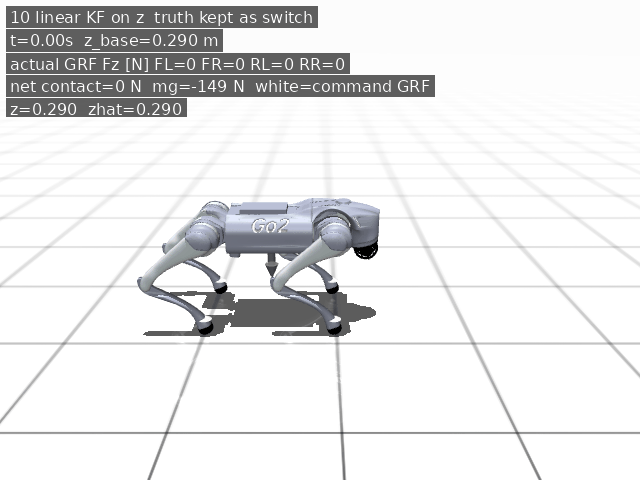

In [2]:

st = {"phi": OFF.copy(), "prev": np.ones(4), "lift": None, "cmd": np.zeros((4, 3)), "zhat": None, "vzhat": 0.0}

def tau_fn(pl):
    """内容: GIF は推定側。"""
    dt = pl.sim_dt
    z = float(pl.base_pos()[2])
    if st["lift"] is None:
        st["lift"] = pl.feet_pos_world().copy()
        st["z0"] = z
        st["zhat"] = z
    z_meas = z + SIGMA * rng.normal()
    st["zhat"] = st["zhat"] + dt * float(pl.base_lin_vel_world()[2])
    st["zhat"] = st["zhat"] + Kz * (z_meas - st["zhat"])
    geoms = pl.foot_geom_ids()
    phi = (st["phi"] + dt * FREQ) % 1.0
    c = (phi < DUTY).astype(float)
    vz = float(pl.base_lin_vel_world()[2])
    grf = plan_grf_equal(np.array([st["zhat"], vz, pl.mass_kg]), c, None, np.array([st["z0"], FX_TINY]))
    feet = pl.feet_pos_world()
    vel = pl.feet_vel_world()
    h = np.asarray(pl.data.qfrc_bias[6:], dtype=np.float64)
    tau = np.zeros(12)
    for i in range(4):
        if st["prev"][i] > 0.5 and c[i] < 0.5:
            st["lift"][i] = feet[i].copy()
        Jleg = jac_leg(pl.model, pl.data, geoms, i)
        sl = slice(3 * i, 3 * i + 3)
        tau[sl] = (h[sl] - Jleg.T @ grf[i]) if c[i] > 0.5 else swing_tau(Jleg, feet[i], vel[i], lift_i := st["lift"][i], phi[i], DUTY, FREQ)
    st["phi"] = phi
    st["prev"] = c
    st["cmd"] = grf
    return clip_torque(tau, pl.model.actuator_ctrlrange)

plant = MujocoGo2(scene="flat", seed=0)
path = render_rollout_gif(
    plant, Path("assets/10_linear_kf.gif"),
    n_steps=int(round(T_RUN / plant.sim_dt)), capture_every=80, tau_fn=tau_fn,
    command_grf=lambda pl: st["cmd"],
    extra_lines=lambda pl: [f"z={pl.base_pos()[2]:.3f}  zhat={st['zhat']:.3f}"],
    title="10 linear KF on z  truth kept as switch",
)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 分析

推定で `plan_grf` しても 5 秒持つ。真値走行も残した。GIF `10_linear_kf.gif`。次は 100 Hz の脚力と 500 Hz の下位。


## 続き — 新判定では未成功

旧セルの hold 5 s と直立ループは、20 s / 10 m / 上流ゲイトの表では不合格である。05 が標準足踏みで 20 s 持つまで、この番号は進めない。失敗ログは残す。
